# import Package for Use

In [21]:
import pandas as pd
import numpy as np

# Read datasets

In [22]:
train_df =pd.read_csv(r'D:\Archmooner\python\ML\Datasets\titanic\train.csv')
test_df = pd.read_csv(r'D:\Archmooner\python\ML\Datasets\titanic\test.csv')

# Check 5 record in data frame train

In [23]:
print(train_df.head())
print("end================================")
print(test_df.head())

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  
en

# Check Missing Value

In [24]:
train_df.info()
test_df.info()

print("train data:")
print(train_df.isnull().sum())
print("test data:")
print(test_df.isnull().sum())

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB
<class 'pandas.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass       418 non-null    int64

# Analisys relation feature of target (survived)

In [25]:
#  Checking the survival rate based on gender
print(train_df[['Sex', 'Survived']].groupby(['Sex']).mean())

# Checking the survival rate based on passenger class
print(train_df[['Pclass', 'Survived']].groupby(['Pclass']).mean())


        Survived
Sex             
female  0.742038
male    0.188908
        Survived
Pclass          
1       0.629630
2       0.472826
3       0.242363


# Cleanning The missing Value

In [27]:
# 2. Imputasi Missing Values
# Age: gunakan median dari train
median_age = train_df["Age"].median()
train_df["Age"] = train_df["Age"].fillna(median_age)
test_df["Age"] = test_df["Age"].fillna(median_age)

# Embarked: gunakan modus dari train
mode_embarked = train_df["Embarked"].mode()[0]
train_df["Embarked"] = train_df["Embarked"].fillna(mode_embarked)
test_df["Embarked"] = test_df["Embarked"].fillna(mode_embarked)

# Fare: tangani nilai kosong di test_df menggunakan median dari train
median_fare = train_df["Fare"].median()
test_df["Fare"] = test_df["Fare"].fillna(median_fare)

# 3. Konversi Fitur Kategori ke Numerik
# Sex: female -> 1, male -> 0
train_df["Sex"] = train_df["Sex"].map({"male": 0, "female": 1})
test_df["Sex"] = test_df["Sex"].map({"male": 0, "female": 1})

# Embarked: One-Hot Encoding
train_df = pd.get_dummies(train_df, columns=["Embarked"], drop_first=True)
test_df = pd.get_dummies(test_df, columns=["Embarked"], drop_first=True)

# 4. Verifikasi hasil
print("Kolom train_df sekarang:")
print(train_df.columns.tolist())
print("\nSisa missing values di train_df:")
print(train_df.isnull().sum())

Kolom train_df sekarang:
['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked_Q', 'Embarked_S']

Sisa missing values di train_df:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked_Q       0
Embarked_S       0
dtype: int64


# import sklearn for get the accuracy and train model use RFC( Random Forest Classifier)

In [29]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

In [ ]:
features = [
    'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare',
    'Embarked_Q', 'Embarked_S'
]

x = train_df[features]
y = train_df['Survived']

X_train, X_val, y_train, y_val = train_test_split(
    x, y, test_size=0.2, random_state=42
)

model = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
model.fit(X_train, y_train)

val_predictions = model.predict(X_val)
acc = accuracy_score(y_val, val_predictions)

print(F"Validation Accuracy: {acc * 100:.2f}%")

Validation Accuracy: 81.56%
X-train:      Pclass  Sex   Age  SibSp  Parch      Fare  Embarked_Q  Embarked_S
331       1    0  45.5      0      0   28.5000       False        True
733       2    0  23.0      0      0   13.0000       False        True
382       3    0  32.0      0      0    7.9250       False        True
704       3    0  26.0      1      0    7.8542       False        True
813       3    1   6.0      4      2   31.2750       False        True
..      ...  ...   ...    ...    ...       ...         ...         ...
106       3    1  21.0      0      0    7.6500       False        True
270       1    0  28.0      0      0   31.0000       False        True
860       3    0  41.0      2      0   14.1083       False        True
435       1    1  14.0      1      2  120.0000       False        True
102       1    0  21.0      0      1   77.2875       False        True

[712 rows x 8 columns]
y-train: 331    0
733    0
382    0
704    0
813    0
      ..
106    1
270    0
860   

# visualisasi Data with matplotlib

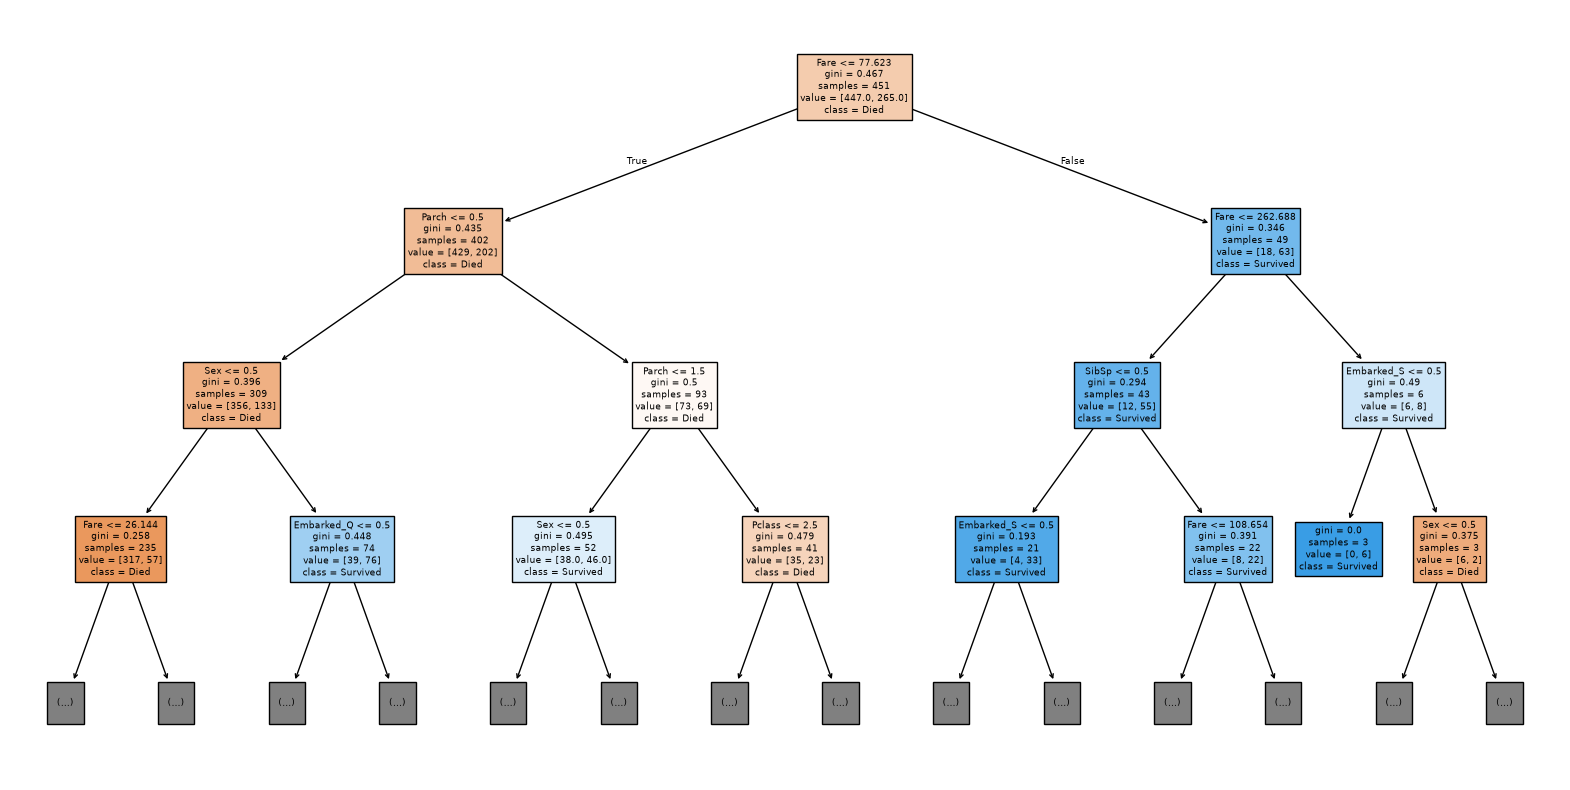

In [40]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(20, 10))
plot_tree(
    model.estimators_[0],
    feature_names=features,
    class_names=['Died', 'Survived'],
    filled=True,
    max_depth=3
)
plt.show()

In [41]:
# Buat tabel perbandingan untuk 179 data validasi
hasil_evaluasi = X_val.copy()
hasil_evaluasi["Kunci_Jawaban_Asli"] = y_val.values
hasil_evaluasi["Tebakan_Model"] = val_predictions
hasil_evaluasi["Tebakan_Benar"] = (
    hasil_evaluasi["Kunci_Jawaban_Asli"] == hasil_evaluasi["Tebakan_Model"]
)

# Tampilkan 10 baris pertama
print(hasil_evaluasi.head(10))

     Pclass  Sex   Age  SibSp  Parch     Fare  Embarked_Q  Embarked_S  \
709       3    0  28.0      1      1  15.2458       False       False   
439       2    0  31.0      0      0  10.5000       False        True   
840       3    0  20.0      0      0   7.9250       False        True   
720       2    1   6.0      0      1  33.0000       False        True   
39        3    1  14.0      1      0  11.2417       False       False   
290       1    1  26.0      0      0  78.8500       False        True   
300       3    1  28.0      0      0   7.7500        True       False   
333       3    0  16.0      2      0  18.0000       False        True   
208       3    1  16.0      0      0   7.7500        True       False   
136       1    1  19.0      0      2  26.2833       False        True   

     Kunci_Jawaban_Asli  Tebakan_Model  Tebakan_Benar  
709                   1              0          False  
439                   0              0           True  
840                   0     